ADVANCED ANALYSIS: Clustering, Correlation

In [ ]:
# =============================================
# STEP 0: Import Required Libraries
# =============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.cluster import KMeans

# Optional display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


In [ ]:
# =============================================
# STEP 1: Load Cleaned Dataset
# =============================================
df = pd.read_csv('cleaned_project_dataset.csv')


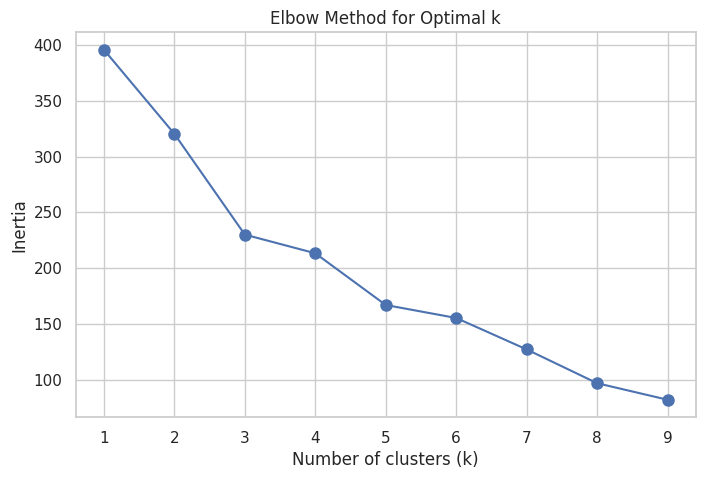

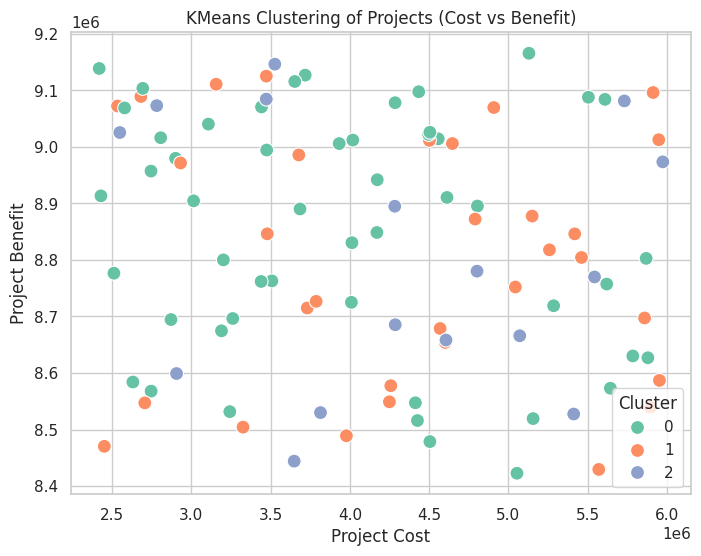

In [ ]:
# =============================================
# STEP 2: Clustering Analysis (KMeans)
# Group projects based on Cost, Benefit, Duration, Complexity
# =============================================
# Features for clustering
cluster_features = df[[' Project Cost ', ' Project Benefit ', 'Duration_Months', 'Complexity_Encoded']]

# Standardize features
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

# Determine number of clusters (k) using Elbow Method
inertia = []
K_range = range(1,10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow curve
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, 'bo-', markersize=8)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

# Fit KMeans with chosen k (e.g., k=3)
kmeans_final = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans_final.fit_predict(cluster_scaled)

# Visualize clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df[' Project Cost '],
    y=df[' Project Benefit '],
    hue=df['Cluster'],
    palette='Set2',
    s=100
)
plt.title("KMeans Clustering of Projects (Cost vs Benefit)")
plt.xlabel("Project Cost")
plt.ylabel("Project Benefit")
plt.show()

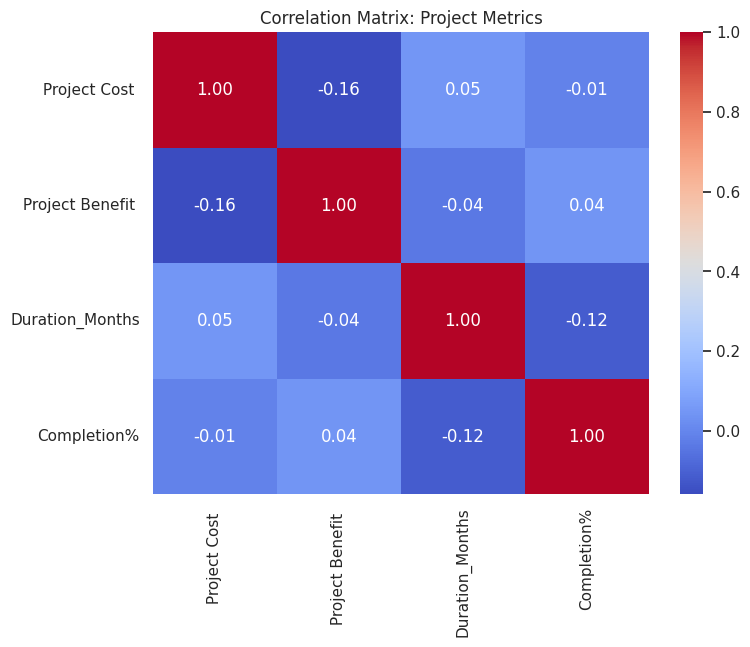

In [ ]:
# =============================================
# STEP 3: Correlation Matrix
# Numeric correlation between Cost, Benefit, Duration, Completion%
# =============================================
numeric_cols = [' Project Cost ', ' Project Benefit ', 'Duration_Months', 'Completion%']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix: Project Metrics")
plt.show()